# Toy diffusion model generating data from a complex 2-d distribution

## General imports

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

## Load training data

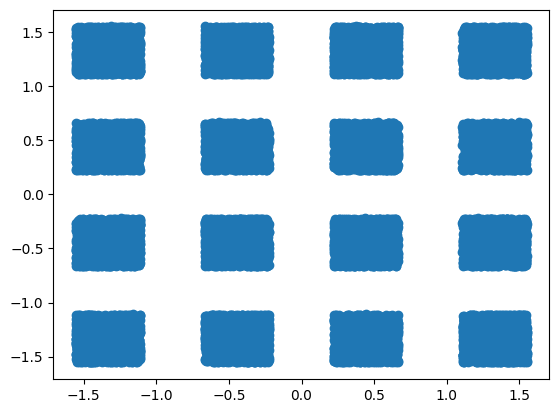

In [2]:
from sklearn.datasets import make_moons
import numpy as np

# def make_chessboard(n_per_square=200, squares_per_side=8):
#     square_size = 1.0
#     data = []

#     for i in range(squares_per_side):
#         for j in range(squares_per_side):
#             # 只在“黑格子”生成点：(i + j) % 2 == 0
#             if (i + j) % 2 == 0:
#                 x = np.random.rand(n_per_square) * square_size + i * square_size
#                 y = np.random.rand(n_per_square) * square_size + j * square_size
#                 points = np.stack([x, y], axis=1)
#                 data.append(points)

#     X = np.concatenate(data, axis=0)
#     return X

def make_sparse_checkerboard(n_samples=100000, n_grid=8):
    x = np.random.rand(n_samples, 2) * n_grid

    x_grid = np.floor(x).astype(int)

    mask = (x_grid[:, 0] % 2 == 0) & (x_grid[:, 1] % 2 == 0)
    x_sparse = x[mask]

    return x_sparse

x = make_sparse_checkerboard()
# Make two-dimensional to easen 

# x = x[:, [0, 2]]

x = (x - x.mean()) / x.std()

plt.scatter(x[:, 0], x[:, 1])

## Prepare data for learning

In [3]:
import torch

X = torch.tensor(x, dtype=torch.float32)

## Diffusion model hyperparameters

In [4]:
num_steps = 100  # Number of steps in the diffusion process

Function that noises a data point following the diffusion process

In [5]:
def noise(Xbatch, t):  # t ~ [0, num_steps - 1]   t=0 means no noise
    eps = torch.randn(size=Xbatch.shape)
    noised = (1 - t / num_steps).repeat(1, Xbatch.shape[1]) * Xbatch + (t / num_steps).repeat(1, Xbatch.shape[1]) * eps
    return noised, eps

Test noising the training data

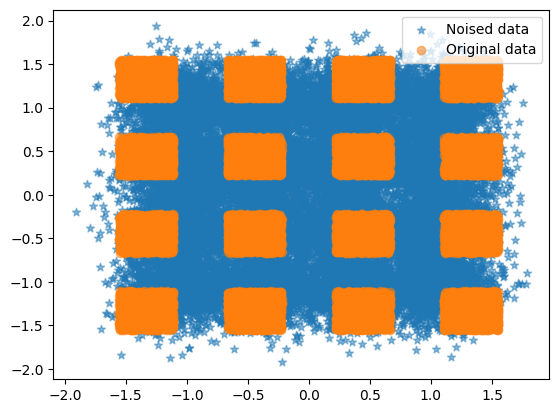

In [6]:
noiselevel = 20

noised, eps = noise(X, torch.full([len(X), 1], fill_value=noiselevel))
plt.scatter(noised[:, 0], noised[:, 1], marker="*", alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.legend(["Noised data", "Original data"])
plt.show()

Since we know the noise we just added, we can recover the original data as follows:

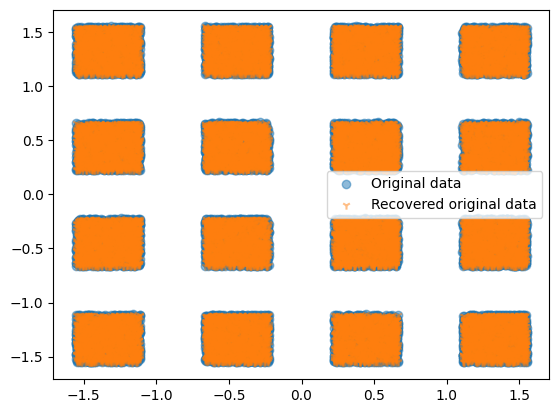

In [7]:
denoised = 1 / (1 - noiselevel/num_steps) * (noised - noiselevel/num_steps * eps)
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.scatter(denoised[:, 0], denoised[:, 1], marker="1", alpha=0.5)
plt.legend(["Original data", "Recovered original data"])
plt.show()

We can also check numerically that the result is the same

In [8]:
X - denoised

tensor([[ 0.0000e+00,  1.1921e-07],
        [ 2.9802e-08,  0.0000e+00],
        [ 2.9802e-08,  0.0000e+00],
        ...,
        [ 0.0000e+00, -2.9802e-08],
        [ 0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00]])

## Diffusion network

Now we define a pytorch network that will learn to predict the noise component from noised data.

In [9]:
import torch.nn as nn

class Block(nn.Module):
    def __init__(self, nunits):
        super().__init__()
        self.linear = nn.Linear(nunits, nunits)
        
    def forward(self, x: torch.Tensor):
        x = self.linear(x)
        x = nn.functional.relu(x)
        return x
        
    
class Toy_Model(nn.Module):
    def __init__(self, nfeatures: int, nblocks: int = 2, nunits: int = 64):
        super().__init__()
        
        self.inblock = nn.Linear(nfeatures+1, nunits)
        self.midblocks = nn.ModuleList([Block(nunits) for _ in range(nblocks)])
        self.outblock = nn.Linear(nunits, nfeatures)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        val = torch.hstack([x, t])  # Add t to inputs
        val = self.inblock(val)
        for midblock in self.midblocks:
            val = midblock(val)
        val = self.outblock(val)
        return val

Let's create a model with 4 inner blocks, which is enough for this problem.

In [10]:
model = Toy_Model(nfeatures=2, nblocks=4)

device = "cuda"
model = model.to(device)

model

Toy_Model(
  (inblock): Linear(in_features=3, out_features=64, bias=True)
  (midblocks): ModuleList(
    (0-3): 4 x Block(
      (linear): Linear(in_features=64, out_features=64, bias=True)
    )
  )
  (outblock): Linear(in_features=64, out_features=2, bias=True)
)

## Train denoising network

In [11]:
import torch.optim as optim

nepochs = 600
batch_size = 2048

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.01, total_iters=nepochs)

for epoch in range(nepochs):
    epoch_loss = steps = 0
    for i in range(0, len(X), batch_size):
        Xbatch = X[i:i+batch_size]
        timesteps = torch.randint(0, num_steps, size=[len(Xbatch), 1])
        noised, eps = noise(Xbatch, timesteps)
        predicted_noise = model(noised.to(device), timesteps.to(device))
        loss = loss_fn(predicted_noise, eps.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss
        steps += 1
    print(f"Epoch {epoch} loss = {epoch_loss / steps}")

Epoch 0 loss = 1.004838228225708
Epoch 1 loss = 0.9757367968559265
Epoch 2 loss = 0.916891872882843
Epoch 3 loss = 0.8140523433685303
Epoch 4 loss = 0.7025205492973328
Epoch 5 loss = 0.623900830745697
Epoch 6 loss = 0.5696048736572266
Epoch 7 loss = 0.5702690482139587
Epoch 8 loss = 0.5480496287345886
Epoch 9 loss = 0.5636530518531799
Epoch 10 loss = 0.5486801266670227
Epoch 11 loss = 0.5439839959144592
Epoch 12 loss = 0.5540227293968201
Epoch 13 loss = 0.5282351970672607
Epoch 14 loss = 0.5289100408554077
Epoch 15 loss = 0.5237298607826233
Epoch 16 loss = 0.510884165763855
Epoch 17 loss = 0.5429261922836304
Epoch 18 loss = 0.533531129360199
Epoch 19 loss = 0.5169429779052734
Epoch 20 loss = 0.520356297492981
Epoch 21 loss = 0.5258986353874207
Epoch 22 loss = 0.4996327757835388
Epoch 23 loss = 0.5144601464271545
Epoch 24 loss = 0.5351064801216125
Epoch 25 loss = 0.512152910232544
Epoch 26 loss = 0.5191265344619751
Epoch 27 loss = 0.5117743015289307
Epoch 28 loss = 0.5059797167778015
Ep

## Sampling algorithm

We will use the classic DDPM sampler, defined as follows

In [12]:
def sample(model, nsamples, nfeatures):
    """Sampler following the Denoising Diffusion Probabilistic Models method by Ho et al (Algorithm 2)"""
    with torch.no_grad():
        x = torch.randn(size=(nsamples, nfeatures)).to(device)
        xt = [x]
        for t in range(num_steps-1, 0, -1):
            predicted_noise = model(x, torch.full([nsamples, 1], t).to(device))

            x0 = 1 / (1 - t/num_steps) * (x - t/num_steps * predicted_noise)
            x  = (1 - (t-1) / num_steps) * x0 + ((t-1) / num_steps) * predicted_noise

            # if t > 1:
            #     variance = betas[t]
            #     std = variance ** (0.5)
            #     x += std * torch.randn(size=(nsamples, nfeatures)).to(device)
            xt += [x]
        return x, xt

## Test generation

Let's generate 10K samples of the learned distribution using the diffusion model we just created

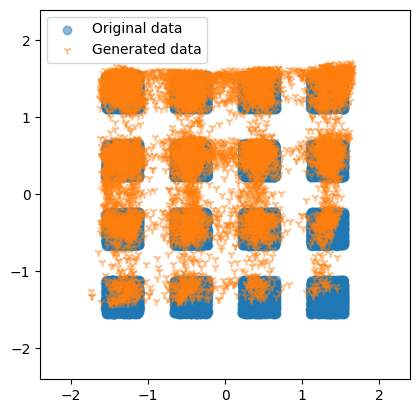

In [13]:
Xgen, Xgen_hist = sample(model, 10000, 2)
Xgen = Xgen.cpu()
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.scatter(Xgen[:, 0], Xgen[:, 1], marker="1", alpha=0.5)
plt.legend(["Original data", "Generated data"])
plt.xlim(-2.4, 2.4)
plt.ylim(-2.4, 2.4)
plt.xticks([-2, -1, 0, 1, 2])
plt.yticks([-2, -1, 0, 1, 2])
plt.gca().set_aspect('equal', adjustable='box')
plt.show()